In [1]:
from src.experimenthandling import ExperimentLoader, ExperimentRunner

In [2]:
loader = ExperimentLoader('experiment_1')
models = loader.load_models()

EpiConfig loaded: _epiconfig.yaml from experiment_1
loaded


In [3]:
for hl, models in models.items():
    for model in models[:1]:  # just first model per horizon
        if model.monitoring_metrics is not None:
            mm = model.monitoring_metrics
            print(f"hl={hl} {model.name}: "
                  f"epochs={len(mm)}, "
                  f"best_val={mm['val_loss'].min():.4f}, "
                  f"final_lr={mm['learning_rate'].iloc[-1]:.2e}, "
                  f"initial_lr={mm['learning_rate'].iloc[0]:.2e}")

hl=1 gcn2-graph1-hl1-s42: epochs=93, best_val=0.1813, final_lr=8.00e-07, initial_lr=1.00e-04


In [9]:
ml= models[1]

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel/training.py:227: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


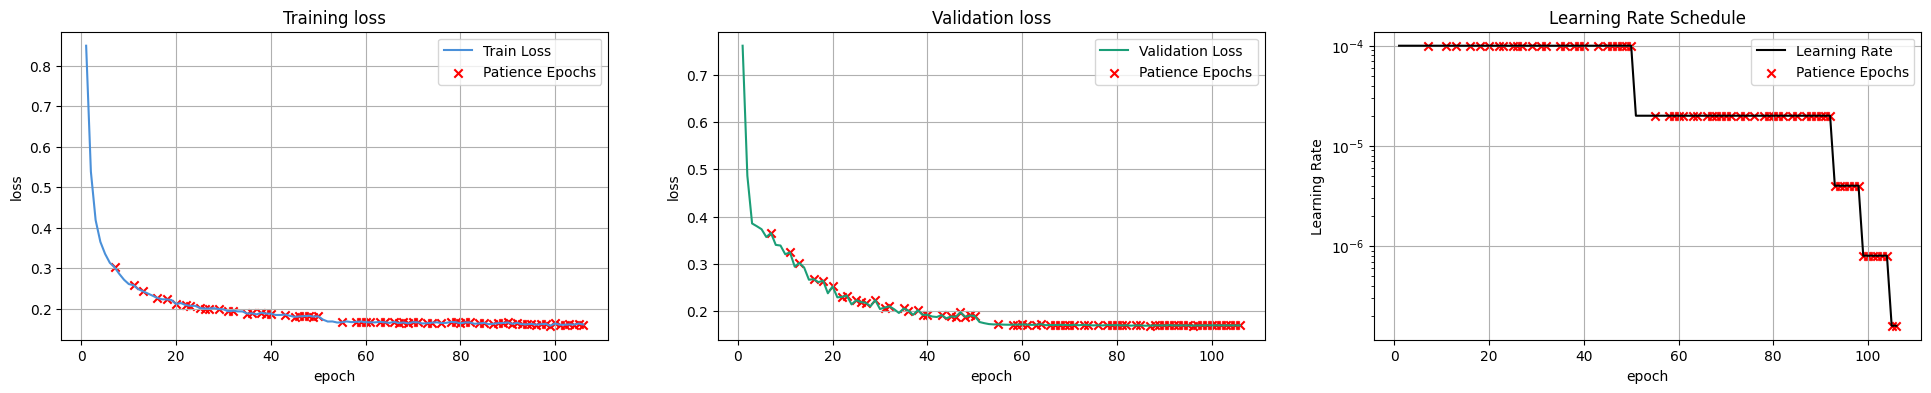

In [11]:
ml.show_monitoring_metrics()

In [12]:
ml.monitoring_metrics

,epoch,train_loss,val_loss,patience,learning_rate
0,1,0.849645,0.760987,False,1.000000e-04
1,2,0.538677,0.486337,False,1.000000e-04
2,3,0.418929,0.385518,False,1.000000e-04
3,4,0.365304,0.379664,False,1.000000e-04
4,5,0.335457,0.373367,False,1.000000e-04
...,...,...,...,...,...
101,102,0.160329,0.170218,True,8.000000e-07
102,103,0.161232,0.170182,True,8.000000e-07
103,104,0.160637,0.170178,True,8.000000e-07
104,105,0.163124,0.170173,True,1.600000e-07


In [ ]:
from typing import Dict, Any, Union, Optional, List, Tuple, TYPE_CHECKING, Literal
import pandas as pd
import torch 
from tqdm import tqdm
from torch.optim.optimizer import Optimizer
from torch.optim.lr_scheduler import _LRScheduler
import seaborn as sns 
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from src.utils.colors import traincolor, valcolor

def show_monitoring_metrics() -> None:
    """Shows plot of trainloss, valloss, patience and learning rate per epoch."""

    if not hasattr(ml, 'monitoring_metrics'):
        raise ValueError('no monitoring metrics found')
    
    fig, axes_array = plt.subplots(1, 3, figsize=(24, 4))
    axes: list[Axes]= list(axes_array.flatten())

    # lines: train_loss, val_loss and learning_rate
    sns.lineplot(data = ml.monitoring_metrics, x='epoch', y='train_loss',   color=traincolor,   label='Train Loss',         ax=axes[0], zorder = 3)
    sns.lineplot(data = ml.monitoring_metrics, x='epoch', y='val_loss',     color=valcolor,     label='Validation Loss',    ax=axes[1], zorder = 3)
    sns.lineplot(data = ml.monitoring_metrics, x='epoch', y='learning_rate',color='black',      label='Learning Rate',      ax=axes[2], zorder = 3)

    # Scatter patience epochs and corresponding values
    _plot_scatter_patience_on_ax('train_loss',     axes[0])
    _plot_scatter_patience_on_ax('val_loss',       axes[1])
    _plot_scatter_patience_on_ax('learning_rate',  axes[2])   

    _draw_best_epoch_arrow('train_loss',     axes[0])
    _draw_best_epoch_arrow('val_loss',       axes[1])
    _draw_best_epoch_arrow('learning_rate',  axes[2])                    


    axes[0].set_title('Training loss')      
    axes[1].set_title('Validation loss')    
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_yscale('log')

    fig.show()

def _plot_scatter_patience_on_ax(y: Literal['train_loss','val_loss','learning_rate'], ax: Axes) -> None:
    """plots red cross for patience epoch on any ax"""
    patience_mask = ml.monitoring_metrics['patience'] > 0

    ax.scatter(x        = ml.monitoring_metrics['epoch'][patience_mask], 
                y        = ml.monitoring_metrics[y][patience_mask], 
                color    ='red', 
                marker   ='x', 
                label    ='Patience Epochs',
                zorder = 1)
    


/local/job_24858540/ipykernel_2641204/3304350588.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


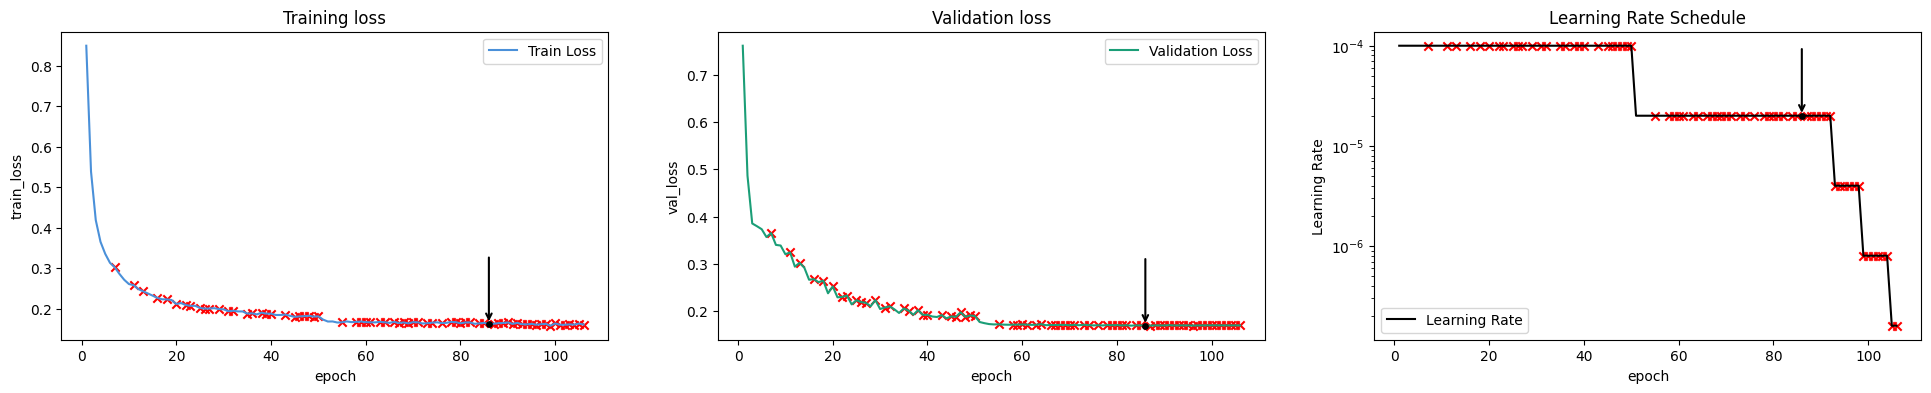

In [60]:
show_monitoring_metrics()

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel/training.py:218: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


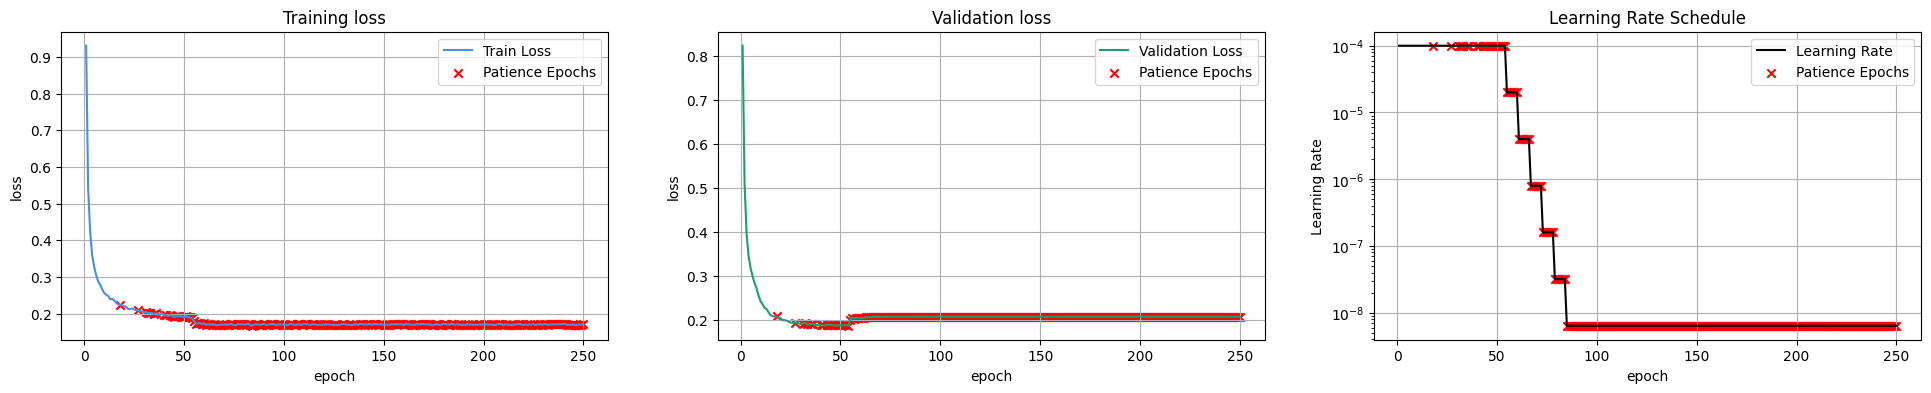

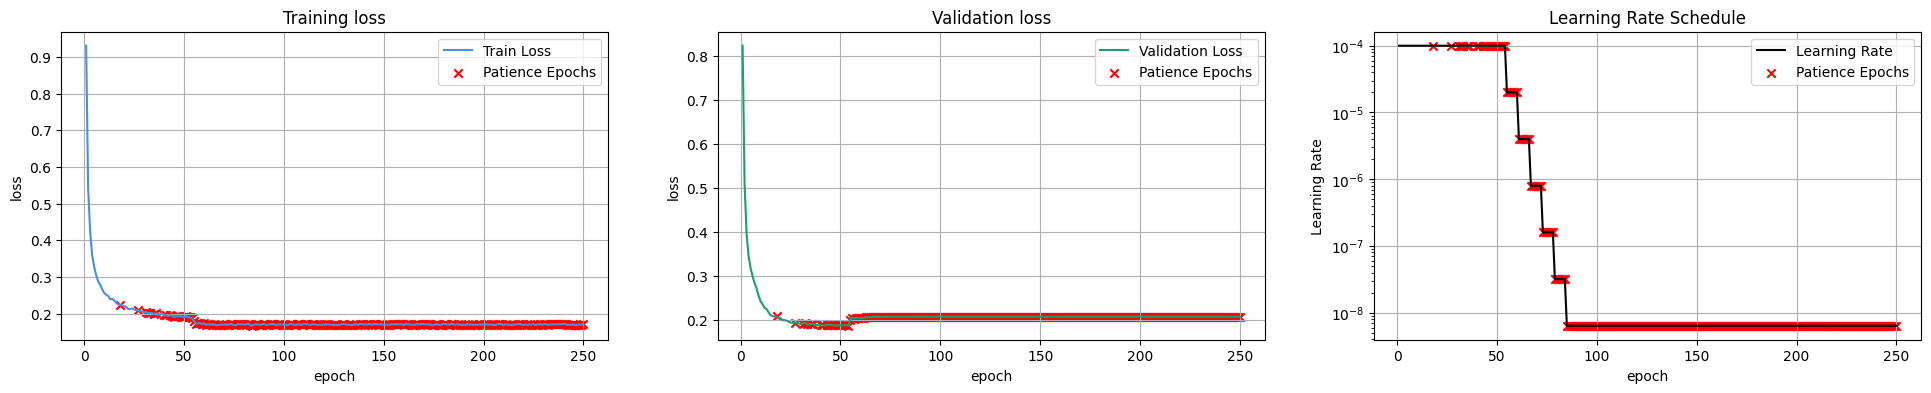

In [37]:
models[1][0].show_monitoring_metrics()